In [7]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [8]:
class MyLinearRegression:
    
    def __init__(self, learning_rate=0.01, epochs=1000):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.m = 0
        self.b = 0
        
    def fit(self, X, y):
        n = len(X)
        
        for _ in range(self.epochs):
            y_pred = self.m * X + self.b
            
            dm = (-2/n) * np.sum(X * (y - y_pred))
            db = (-2/n) * np.sum(y - y_pred)
            
            self.m = self.m - self.learning_rate * dm
            self.b = self.b - self.learning_rate * db
    
    def predict(self, X):
        return self.m * X + self.b

In [9]:
data = pd.read_csv('./data/Housing.csv')

X = data['area'].values
y = data['price'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
#NORMALIZATION : makes values small / close to zero so i can calculate by 0.01
X_train = X_train / X_train.max()
y_train = y_train / y_train.max()

my_obj = MyLinearRegression()
my_obj.fit(X_train , y_train)
print(my_obj.m)
print(my_obj.b)

0.2414133795608502
0.309141743064734


In [11]:
predictions = my_obj.predict(X_train)

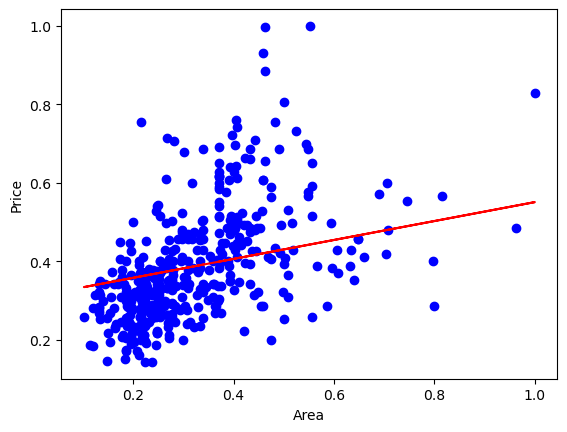

In [13]:
plt.scatter(X_train, y_train, color='blue')
plt.plot(X_train, predictions, color='red')
plt.xlabel("Area")
plt.ylabel("Price")
plt.show()